# 1D optimal command latching using Pontryagin's maximum principle.

# Maths used -

For this method the **equation of motion** used is: 
$$
(M+\mu_{\infty})\ddot{\zeta}
+\int_{0}^{t} \dot{\zeta}(\tau)K(t-\tau)d\tau
+(B+Gu(t))\dot{\zeta}
+k\zeta
=F_{\mathrm{ex}}(t)
$$

u is stored as a binary sequence of 1 (latch) and 0 (no latch) for each time evaluated. G is a large value which (physically) oposes the motion of the bouy when latched.

Time domain impulse response for BEM frequency spectrum $\omega$ and frequency domain radiation damping $B(\omega)$
$$
K(t) = \frac{2}{\pi} \int_{0}^{\infty} B(\omega)\cos(\omega t)\, d\omega
$$

(this is a fourier cosine transform)

We can approximate it with a **Reimann sum** since Capytaine returns a *discretized frequency spectrum*:

$$
K(t) \approx \frac{2}{\pi} \sum_{j=1}^{N} B(\omega_j)\cos(\omega_j t)\,\Delta\omega_j
$$

Then we approximate it using **prony's method** since this allows us to convert the equation of motion from an *integro-differential equation* to a *differential equation* which can then be converted to a first order ODE using state space substituion (this is a form that works with solve_ivp)

Prony's approximation:

$$
K(t) \approx \sum_{n=1}^{N} \alpha _n e^{\beta _n t}
$$

We find the coefficients $\alpha_n, \beta_n \in \mathbf{C}$ by fitting the prony expansion to the *Reimann sum* evaluation of $K(t)$. Which then enables us to rewrite the radiation memory term as such:

$$
\int_{0}^{t} \dot{\zeta}(\tau)K(t-\tau)d\tau
\approx
\sum_{i=1}^{N}
\int_{0}^{t}
\dot{\zeta}(\tau),\alpha_i e^{\beta_i (t-\tau)},d\tau
$$

$$
I_i = 
\int_{0}^{t}
\dot{\zeta}(\tau),\alpha_i e^{\beta_i (t-\tau)},d\tau
$$

The original **integro-differential equation of motion** can now be written as a **differential equation**:

$$
(M + \mu_\infty) \ddot{\zeta} + \sum_{i=1}^{N} I_i^{R} + B \dot{\zeta} + k \zeta = F_{\text{ex}}(t)
$$


$$
\dot{I_i} = 
\beta_i I_i
+
\alpha_i \dot{\zeta}
$$

We can then use *state-space substitution* to set up an O.D.E for **the state of the system**, $X$:

$$
X =
\begin{bmatrix}
\zeta \\
\dot{\zeta} \\
I_i^{R} \\
I_i^{I} \\
\end{bmatrix}
$$

$$
\dot{X} =
\begin{bmatrix}
\dot{\zeta} \\
\frac{1}{M + \mu_\infty} \left[ F_{\text{ex}}(t) - (B + Gu(t))\dot{\zeta} - k \zeta - \sum_{i} I_i^{R} \right]\\
β_i^{R}​I_i^{R}​−β_i^{I}​I_i^{I}​+α_i^{R}​\dot{\zeta}​\\
β_i^{I}​I_i^{R}​−β_i^{R}​I_i^{I}​+α_i^{I}​\dot{\zeta}\\
\end{bmatrix}
$$

The latch state at each time is then determined via the **Hamiltonian**, $H$. $H$ is an instantaneous score: the power you're capturing right now, plus a weighted sum of how your current state trajectory is affecting future energy capture. The λ terms are the adjoint terms and encode the "look-ahead" — they carry information from the future backwards in time, and are used to evaluate whether latching will increase or decrease future energy capture.

$$
H = B v^2 + \lambda_1 v + \lambda_2 \Bigg[f_{ex} - \frac{1}{M + \mu_\infty} (B + G u) v - \frac{k}{M + \mu_\infty} z - \frac{1}{M + \mu_\infty} \sum_{i=1}^N I_i^R \Bigg] \tag{43} \\
+ \sum_{i=1}^N \left[ \lambda_i^R \left( \beta_i^R I_i^R - \beta_i^I I_i^I + \alpha_i^R v \right) + \lambda_i^I \left( \beta_i^R I_i^I + \beta_i^I I_i^R + \alpha_i^I v \right) \right]
$$
The adjoint components of the adjoint vector are found by solving $\dot{\lambda}_i = -\frac{\partial H}{\partial X_i}$.
$$
\begin{aligned}
\dot{\lambda}_1 &= \frac{k}{M + \mu_\infty} \lambda_2 \\
\\
\dot{\lambda}_2 &= -2B v - \lambda_1 + \frac{\lambda_2}{M + \mu_\infty} (B + G u)
- \sum_{i=1}^{N} \left( \lambda_i^{R}\alpha_i^{R} + \lambda_i^{I}\alpha_i^{I} \right) \\
\\
\dot{\lambda}_i^{R} &= -\lambda_i^{R}\beta_i^{R} - \lambda_i^{I}\beta_i^{I}
+ \frac{\lambda_2}{M+\mu_\infty} \\
\\
\dot{\lambda}_i^{I} &= \lambda_i^{R}\beta_i^{I} - \lambda_i^{I}\beta_i^{R}
\end{aligned}
$$

The hamiltonian is maximised when u follows this control function: 

$$
u = \begin{cases} 
1 & \text{if } -\lambda_2 G v > 0 \\ 
0 & \text{otherwise}
\end{cases}
$$

# Algorithm

In [1]:
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.interpolate import interp1d
from prony_quick_check import quick_prony_check
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def compute_K(t_grid, omega, B):
    """This approximates K(t) for all time points in the t_array, using a reimann sum approximation.
    """
    # t_array is a vector, so K needs to be 2D temporarily
    K = np.zeros_like(t_grid, dtype=float)
    
    for j in range(len(omega)-1):
        dw = omega[j+1] - omega[j]   # local spacing
        K += B[j] * np.cos(omega[j] * t_grid) * dw
    
    return (2/np.pi) * K

def prony_model(t_grid, *params):
    """
    This function finds the prony series at the time points in t, given the parameters in params.
    Use: it is used in curve_fit to find the optimal *params that fit the K(t) data.

    Inputs:
    - t: a vector of time points
    - params: a list of paramaters, (Re(alpha_1), Re(beta_1), Im(alpha_1), Im(beta_1),   Re(alpha_2), Re(beta_2), Im(alpha_2), Im(beta_2), ...)

    Outputs:
    - result - type(list):T This is the prony series evaluated at all the time points"""
    params = np.array(params)
    N = len(params) // 4

    result = np.zeros_like(t_grid)

    for i in range(N):
        alpha_R = params[4*i]
        beta_R  = params[4*i+1]
        alpha_I = params[4*i+2]
        beta_I  = params[4*i+3]

        result += alpha_R*np.exp(beta_R*t_grid)*np.cos(beta_I*t_grid)
        result -= alpha_I*np.exp(beta_R*t_grid)*np.sin(beta_I*t_grid)

    return result

def init_prony_guess(omega_n, zeta, K_max, N=4):
    """
    This guesses initial prony coefficients using physical parameters.
    
    Parameters:
    -----------
    omega_n : float
        Natural frequency of WEC [rad/s]
    zeta : float
        Damping ratio (dimensionless, typically 0.1-0.3)
    K_max : float
        Maximum value of K(t) (for amplitude scaling)
    N : int
        Number of Prony terms
        
    Returns:
    --------
    guess : ndarray
        Initial guess, shape (N, 4)
    """
    
    # Damped natural frequency
    omega_d = omega_n * np.sqrt(1 - zeta**2)
    
    # Decay rate from damping ratio
    decay_rate = -abs(zeta * omega_n)
    
    # Generate guess with terms around natural frequency
    guess = np.zeros((N, 4))
    for i in range(N):
        # Spread terms around natural frequency
        freq_factor = 0.5 + i*0.5  # 0.5, 1.0, 1.5, 2.0 * ω_n
        
        guess[i, 0] = K_max / (i + 1)                  # αᴿ
        guess[i, 1] = decay_rate * (0.5 + i*0.3)      # βᴿ: varying decay
        guess[i, 2] = K_max / (2*(i + 1))             # αᴵ
        guess[i, 3] = omega_d * freq_factor           # βᴵ: around ωₙ
        
    return guess

def find_stable_prony(t_grid, K_data, p0, N_prony=4):

    def objective(params):
        K_fit = prony_model(t_grid, *params)
        return np.sum((K_data - K_fit)**2)
    
    # Bounds: force Re(β) < 0
    bounds = []
    for i in range(N_prony):
        bounds.append((-np.inf, np.inf))    # αᴿ: free
        bounds.append((-10, -0.001))        # βᴿ: MUST be negative
        bounds.append((-np.inf, np.inf))    # αᴵ: free
        bounds.append((-5, 5))              # βᴵ: reasonable frequencies
    
    result = minimize(objective, p0.flatten(), method = "L-BFGS-B", bounds=bounds)
    return result.x.reshape(-1, 4)

In [3]:
def interleave(a, b):
    out = np.empty(a.size + b.size, dtype=a.dtype)
    out[0::2] = a
    out[1::2] = b
    return out

def WEC_state_rhs(t, y, params, prony_coeffs, f_ex, u_interp):
    """This is the right hand side of the system state O.D.E, it is passed to
    the solve_ivp for the forward integration (Step 2.1 of pontryagin_sol).
    
    Inputs:
    ------
        t, y:
            required inputs for solve_ivp scipy functionality.
        params : tuple
            Contains all relevant parameters in the equation of motion. (Mass, Hydrodynamic Mass, PTO damping coeff, G, Buoyancy)
        prony_coeffs : list
            These are the fitted prony_coefficients.
        f_ex : function
            This is a function which returns the excitation force for a given input time
        u_interp : function
            With this function, latching state can be interpolated at time t (1 = latched, 0 = unlatched).
    Output:
    ------
        The rhs of the system state vector O.D.E."""
    
    # Unpack parameters
    m, m_inf, d, G, k = params
    alpha_R = prony_coeffs[:, 0] # List of Re(alpha_i)
    beta_R  = prony_coeffs[:, 1] # List of Re(beta_i)
    alpha_I = prony_coeffs[:, 2] # # List of Im(alpha_i)
    beta_I  = prony_coeffs[:, 3] # List of Im(beta_i)

    # Unpack the state vector, y
    z = y[0]
    zdot = y[1]
    I_R  = y[2::2]   # indices 2, 4, 6...
    I_I  = y[3::2]   # indices 3, 5, 7...

    # calculate the force from JONSWAP?
    Fex = f_ex(t)
    
    # Interpolate latch state
    u = u_interp(t)

    zddot = (Fex - k*z - (d + G*u)*zdot - np.sum(I_R))/ (m + m_inf)
    dI_R  = beta_R * I_R - beta_I * I_I + alpha_R * zdot
    dI_I  = beta_I * I_R + beta_R * I_I + alpha_I * zdot

    return [zdot, zddot, *interleave(dI_R, dI_I)]


def state_adjoint_rhs(t, lam, params, prony_coeffs, state_interp, u_interp):
    """This is the right hand side of the adjoint vector O.D.E, it is passed to
    the solve_ivp in the backward integration (Step 2.2 of pontryagin_sol).
    
    Inputs:
    --------
        t, lam:
            required inputs for solve_ivp scipy functionality.
        params : tuple:
            Contains all relevant parameters in the equation of motion. (Mass, Hydrodynamic Mass, PTO damping coeff, G, Buoyancy)
        prony_coeffs : list
            These are the fitted prony_coefficients.
        state_interp : solve_ivp object
            Using the .sol attribute we can interpolate the solution at any time point. 
        u_interp : function
            With this function, latching state can be interpolated at time t (1 = latched, 0 = unlatched).
    Output:
    --------
        The rhs of the adjoint vector O.D.E, for the current state."""
    # lam is the adjoint state vector, same size as y
    m, m_inf, d, G, k = params
    alpha_R = prony_coeffs[:, 0] # List of Re(alpha_i)
    beta_R  = prony_coeffs[:, 1] # List of Re(beta_i)
    alpha_I = prony_coeffs[:, 2] # # List of Im(alpha_i)
    beta_I  = prony_coeffs[:, 3] # List of Im(beta_i)
    
    # get the FORWARD state at this time from stored interpolation
    y = state_interp.sol(t) # Interpolate solution, since sol_ivp.output = dense
    zdot = y[1]
    u = u_interp(t)
    
    # Unpack adjoint vector, lam
    lam_1 = lam[0] 
    lam_2 = lam[1]
    lam_R = lam[2::2]
    lam_I = lam[3::2]

    
    dlam_1 =  lam_2 * k / (m + m_inf)
    
    dlam_2 = (-2*d*zdot - lam_1 
              + lam_2*(d + G*u)/(m + m_inf)
              - np.sum(lam_R*alpha_R + lam_I*alpha_I))
    
    dlam_R = -lam_R*beta_R - lam_I*beta_I + lam_2/(m + m_inf)
    dlam_I =  lam_R*beta_I - lam_I*beta_R
    
    return [dlam_1, dlam_2, *interleave(dlam_R, dlam_I)]

In [4]:
def pontryagin_sol(omega, B, times, params, f_ex, max_iter = 200, N = 5):
    """Runs the main pontryagin solution algorithm.
    
    Inputs:
        omega - type(list):
            A list of the frequency spectrum of the simulated waves. e.g. JONSWAP
        B - type(list):
            A list of the radiation damping, B(omega), for each frequency. This should be given by Capytaine
        times - type(list):
            Discretized time range
        params - type(tuple):
            Contains all relevant parameters in the equation of motion. (Mass, Hydrodynamic Mass, PTO damping coeff, G, Buoyancy)
        f_ex - type(function):
            This is a function which returns the excitation force for a given input time

    Outputs:
        u_vals - type(list):
            The optimal latch state at each time step, found by iterating until convergence of the latch states in Step 2
        state_sol - type(OdeResult):
            The solution of the state ODE, with the optimal latch states, found in Step 2
        adjoint_sol - type(OdeResult):
            The solution of the adjoint ODE, found in Step 2"""
    # Extract the parameters in the equation of motion
    m, m_inf, d, G, k = params
    t_grid = times
    u_vals = np.ones_like(t_grid) # Latch state at each time step, initialise as permenant latching to pass to the while loop



    #  --- STEP 1: Solve Prony Approximation ---
    # Compute the approximate impulse response, K(t), for all t.
    K_data = compute_K(t_grid, omega, B)

    omega_n = np.sqrt(k / (m + m_inf))
    zeta = d / (2 * np.sqrt(k * (m + m_inf)))
    K_max = np.max(np.abs(K_data))
    
    X0 = np.zeros(2 + 2*N)  # inital condition [z, zdot, I_R1, I_I1, ..., I_RN, I_IN]

    prony_coeffs_guess = init_prony_guess(omega_n, zeta, K_max, N = N)
    print("initial prony coeffs guess", prony_coeffs_guess)

    # Now find prony coefficients guess with stable poles
    p0_stable = find_stable_prony(t_grid, K_data, prony_coeffs_guess, N_prony=N)

    # Now find the optimal prony coefficients with curve fit, using the stable guess as the initial condition
    popt,_ = curve_fit(prony_model, t_grid, K_data, p0=p0_stable.flatten())

    prony_coeffs = popt.reshape(-1, 4) # reformat prony coefficients, each row is an N
    is_valid, metrics = quick_prony_check(t_grid, K_data, prony_coeffs, prony_model, verbose=True)
    print("Prony_fit is valid:", is_valid)



    # --- Step 2: Iterate until convergence of latch states ---
    u_vals_new = np.zeros_like(u_vals)
    iter_count=0
    diff = np.sum(u_vals_new != u_vals) # The number of t_grid points where the latch state has changed since the last iteration.

    while not np.array_equal(u_vals, u_vals_new) and iter_count < max_iter and diff > 10:
        diff = np.sum(u_vals_new != u_vals)
        print("diff:", diff)
        # print("u_new =", u_vals_new)
        iter_count +=1
        print("iteration", iter_count)


        u_vals = u_vals_new.copy()  # Update the latch states

        # We must define a new u_func since u_vals has changed
        u_func = interp1d(t_grid, u_vals, kind="previous", fill_value="extrapolate")    # Returns latch state for a time step input u_func(t). This is a continuous function which relies on interpolation. 


        # --    Step 2.1: Integrate the state forward to find the state at each time    
        state_sol = solve_ivp(WEC_state_rhs, 
                              [t_grid[0], t_grid[-1]], 
                              X0, 
                              args=(params, prony_coeffs, f_ex, u_func), 
                              dense_output=True,
                              method = "LSODA",
                              max_step=0.5,
                              t_eval=t_grid)    # Ensures more accurate results at specific time points
        

        # --    Step 2.2: Integrate backward to solve the adjoint O.D.E     
        # Here we must integrate backward, so flip the time span
        adjoint_sol = solve_ivp(state_adjoint_rhs, 
                                [t_grid[-1], t_grid[0]], 
                                np.zeros_like(X0),      # lam(t) = 0 for all lam_i
                                args = (params, prony_coeffs, state_sol, u_func), 
                                dense_output=True, 
                                method = "LSODA",
                                max_step=0.5,
                                t_eval = t_grid[::-1])    # Ensures more accurate results at specific time points
        

        # --    Step 2.3: Now find the updated optimal latch state at each time
        for i, t in enumerate(t_grid):

            lam_2 = adjoint_sol.sol(t)[1]
            zdot = state_sol.sol(t)[1]

            if -lam_2*G*zdot > 0:   # If latching increases the Hamiltonian, then latch
                u_vals_new[i] = 1

            else:   # Otherwise, don't latch
                u_vals_new[i] = 0

        indices = [i for i, value in enumerate(u_vals_new) if value == 1]

        # print("indices:", len(indices))
        
        # print(u_vals_new)
                
    return u_vals, state_sol, adjoint_sol



def no_latch_solution(omega, B, times, params, f_ex, max_iter = 200, N = 5):
    # Extract the parameters in the equation of motion
    m, m_inf, d, G, k = params
    t_grid = times
    u_func = lambda t: 0 # Latch state at each time step set to 0.

    K_data = compute_K(t_grid, omega, B)

    omega_n = np.sqrt(k / (m + m_inf))
    zeta = d / (2 * np.sqrt(k * (m + m_inf)))
    K_max = np.max(np.abs(K_data))

    X0 = np.zeros(2 + 2*N)  
    prony_coeffs_guess = init_prony_guess(omega_n, zeta, K_max, N = N)
    print(prony_coeffs_guess)
    # Now find prony coefficients guess with stable poles
    p0_stable = find_stable_prony(t_grid, K_data, prony_coeffs_guess, N_prony=N)
    print(p0_stable)
    prony_coeffs = p0_stable
    # # Now find the optimal prony coefficients with curve fit, using the stable guess as the initial condition
    # popt,_ = curve_fit(prony_model, t_grid, K_data, p0=p0_stable.flatten())

    # prony_coeffs = popt.reshape(-1, 4) # reformat prony coefficients, each row is an N
    is_valid, metrics = quick_prony_check(t_grid, K_data, prony_coeffs, prony_model, verbose=True)
    print("Prony_fit is valid:", is_valid)

    state_sol = solve_ivp(WEC_state_rhs, 
                              [t_grid[0], t_grid[-1]], 
                              X0, 
                              args=(params, prony_coeffs, f_ex, u_func), 
                              dense_output=True,
                              method = "LSODA",
                              max_step=0.5,
                              t_eval=t_grid)
    
    return state_sol

# Toy Data set and Pontryagin numerical solution

*Note: The prony approximation doesn't always work as of yet, i.e. low $R^2$ and unstable poles. This can harm solutions and is something that should be optimized.*

# Steps
1: Run Capytaine BEM solver over a frequency spectrum
This cell solves for the hydrodynamic properties of your buoy across multiple wave frequencies:

2: Set up time grid and excitation force function
This converts the frequency-domain Capytaine data into a time-domain forcing:

3: Set up parameters and call pontryagin_sol
This runs your optimal control algorithm:

4: Visualize results:
-   Top plot: Latch state over time (step function, 0 or 1)
-   Middle plot: Buoy displacement response to waves
-   Bottom plot: Buoy velocity (needed for force calculation)

[15:26:35] WARNING  Mesh resolution for 52 problems:                                                               
                    The resolution of the mesh might be insufficient for omega ranging from 1.771 to 3.000.        
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

           WARNING  Irregular frequencies for 38 problems:                                                         
                    Irregular frequencies might be encountered for omega ranging from 2.115 to 3.000.              
                    Setting a lid for the floating body is recommended.

Output()

μ∞ = 178444.7 kg
k  = 789737.5 N/m

Natural period : 4.96 s  (paper says ~10 s)
Wave period    : 12.00 s
RMS F_ex       : 1283807.0 N
G              : 3.940e+07 N·s/m
Prony fit R²: 0.9750


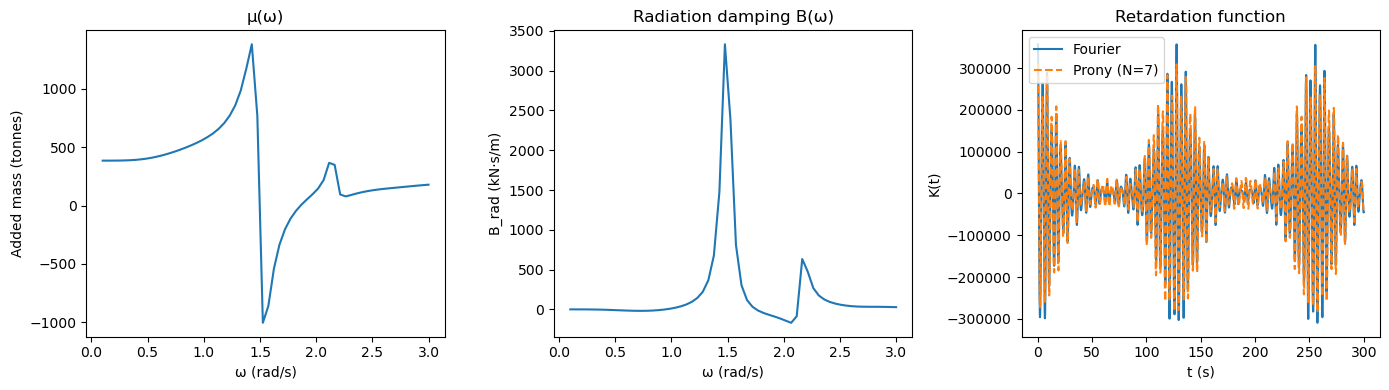

In [5]:
import capytaine as cpt
import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# ── 1. Define geometry: vertical cylinder ─────────────────────────────
# Matches paper: radius=5m, height=20m, submerged 10m
radius   = 5.0
height   = 20.0
centre_z = -10.0   # centre of cylinder below waterline

mesh = cpt.mesh_vertical_cylinder(
    radius=radius,
    length=height,
    center=(0, 0, centre_z),
    resolution=(10, 10, 5)
)

body = cpt.FloatingBody(mesh, name="heaving_buoy")
body.add_translation_dof(name="Heave")   # only heave DOF

# ── 2. Set up BEM problem over frequency range ────────────────────────
omega_range = np.linspace(0.1, 3.0, 60)  # rad/s

problems = [
    cpt.RadiationProblem(body=body, radiating_dof="Heave", omega=w)
    for w in omega_range
] + [
    cpt.DiffractionProblem(body=body, wave_direction=0.0, omega=w)
    for w in omega_range
]

# ── 3. Solve BEM ──────────────────────────────────────────────────────
solver  = cpt.BEMSolver()
results = solver.solve_all(problems, progress_bar=True)
dataset = cpt.assemble_dataset(results)

# ── 4. Extract outputs ────────────────────────────────────────────────

# Added mass and radiation damping vs frequency
added_mass = dataset['added_mass'].sel(
    radiating_dof='Heave', influenced_dof='Heave').values        # μ(ω)
B_rad      = dataset['radiation_damping'].sel(
    radiating_dof='Heave', influenced_dof='Heave').values        # B(ω)

# Infinite frequency added mass μ∞ — take highest frequency value
m_inf = float(added_mass[-1])
print(f"μ∞ = {m_inf:.1f} kg")

# Hydrostatic stiffness k = ρ g A_wp
rho  = 1025.0
g    = 9.81
A_wp = np.pi * radius**2
k    = rho * g * A_wp
print(f"k  = {k:.1f} N/m")

# Excitation force magnitude vs frequency
F_ex_amp = np.abs(
    dataset['Froude_Krylov_force'].sel(
        influenced_dof='Heave', wave_direction=0.0).values
    + dataset['diffraction_force'].sel(
        influenced_dof='Heave', wave_direction=0.0).values
)   # |F_ex(ω)|, N/m  (per unit wave amplitude)

# ── 5. Compute K(t) via Fourier transform of B(ω) ────────────────────
# K(t) = (2/π) ∫ B(ω) cos(ωt) dω
t_grid = np.arange(0, 300.0, 0.05)

K_data = compute_K(t_grid, omega_range, B_rad)



# ── 7. Build excitation force time series (regular wave) ──────────────
M      = 314_000.0     # kg, matches paper
T_wave = 12.0          # s, longer than natural period → good for latching
omega_wave = 2*np.pi / T_wave
A_wave = 1.0           # m wave amplitude

# ── 7. Build excitation force time series (irregular sea) ────────────
A_wave = 1.0
N_comp = 30

omega_components = np.linspace(0.2, 2.0, N_comp)
phi = np.random.uniform(0, 2*np.pi, N_comp)

F_ex_interp = interp1d(omega_range, F_ex_amp, kind='cubic')

f_ex_vals = np.zeros_like(t_grid)

for w, phase in zip(omega_components, phi):
    dw = omega_components[1] - omega_components[0]
    F_amp = float(F_ex_interp(w)) * np.sqrt(dw)
    f_ex_vals += F_amp * np.cos(w * t_grid + phase)

f_ex = interp1d(t_grid, f_ex_vals, kind='cubic', fill_value='extrapolate')

# ── 8. Bundle params and print summary ───────────────────────────────
d = 50_000.0           # PTO damping B, N·s/m
G = 80 * (M + m_inf)   # latching gain, matches paper

params = (M, m_inf, d, G, k)

omega_n = np.sqrt(k / (M + m_inf))
T_n     = 2*np.pi / omega_n
print(f"\nNatural period : {T_n:.2f} s  (paper says ~10 s)")
print(f"Wave period    : {T_wave:.2f} s")
print(f"RMS F_ex       : {np.std(f_ex_vals):.1f} N")
print(f"G              : {G:.3e} N·s/m")
# ── 6. Fit Prony series to K(t) ───────────────────────────────────────

# Initial guess: 4 terms, all stable (negative beta_R)
omega_n = np.sqrt(k / (M + m_inf))
zeta1 = d / (2 * np.sqrt(k * (M + m_inf)))
K_max1 = np.max(np.abs(K_data))
p0 = init_prony_guess(omega_n, zeta1, K_max1, N = 7)

popt, _ = curve_fit(prony_model, t_grid, K_data, p0=p0, maxfev=20000)
prony_coeffs = popt.reshape(-1, 4)

# Check fit quality
K_fit = prony_model(t_grid, *popt)
print(f"Prony fit R²: {1 - np.sum((K_data-K_fit)**2)/np.sum((K_data-np.mean(K_data))**2):.4f}")
# ── 9. Quick sanity plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(omega_range, added_mass / 1e3)
axes[0].set(xlabel='ω (rad/s)', ylabel='Added mass (tonnes)', title='μ(ω)')

axes[1].plot(omega_range, B_rad / 1e3)
axes[1].set(xlabel='ω (rad/s)', ylabel='B_rad (kN·s/m)', title='Radiation damping B(ω)')

axes[2].plot(t_grid, K_data, label='Fourier')
axes[2].plot(t_grid, K_fit, '--', label=f'Prony (N={prony_coeffs.shape[0]})')
axes[2].set(xlabel='t (s)', ylabel='K(t)', title='Retardation function')
axes[2].legend()

plt.tight_layout()
plt.show()

Text(0, 0.5, 'F_ex (N)')

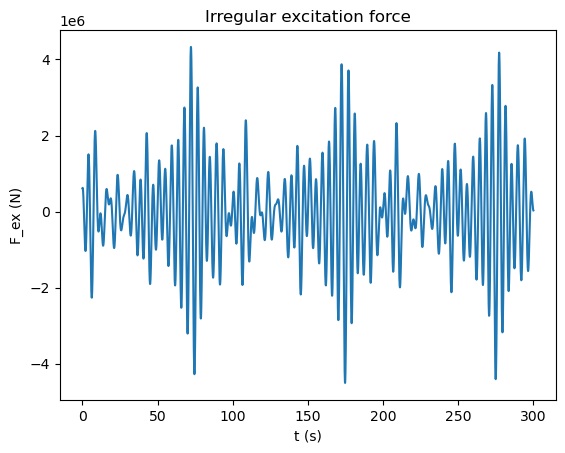

In [6]:
plt.figure()
plt.plot(t_grid, f_ex_vals)
plt.title("Irregular excitation force")
plt.xlabel("t (s)")
plt.ylabel("F_ex (N)")


Ready to call:
initial prony coeffs guess [[ 3.57193516e+05 -2.53835595e-02  1.78596758e+05  6.32678943e-01]
 [ 1.78596758e+05 -4.06136951e-02  8.92983791e+04  1.26535789e+00]
 [ 1.19064505e+05 -5.58438308e-02  5.95322527e+04  1.89803683e+00]
 [ 8.92983791e+04 -7.10739665e-02  4.46491895e+04  2.53071577e+00]
 [ 7.14387033e+04 -8.63041021e-02  3.57193516e+04  3.16339471e+00]
 [ 5.95322527e+04 -1.01534238e-01  2.97661264e+04  3.79607366e+00]
 [ 5.10276452e+04 -1.16764373e-01  2.55138226e+04  4.42875260e+00]
 [ 4.46491895e+04 -1.31994509e-01  2.23245948e+04  5.06143154e+00]
 [ 3.96881685e+04 -1.47224645e-01  1.98440842e+04  5.69411048e+00]
 [ 3.57193516e+04 -1.62454781e-01  1.78596758e+04  6.32678943e+00]
 [ 3.24721378e+04 -1.77684916e-01  1.62360689e+04  6.95946837e+00]]


C:\Users\meerk\AppData\Local\Temp\ipykernel_22356\347328418.py:35: RuntimeWarning: overflow encountered in exp
  result += alpha_R*np.exp(beta_R*t_grid)*np.cos(beta_I*t_grid)
C:\Users\meerk\AppData\Local\Temp\ipykernel_22356\347328418.py:35: RuntimeWarning: overflow encountered in multiply
  result += alpha_R*np.exp(beta_R*t_grid)*np.cos(beta_I*t_grid)
C:\Users\meerk\AppData\Local\Temp\ipykernel_22356\347328418.py:36: RuntimeWarning: overflow encountered in exp
  result -= alpha_I*np.exp(beta_R*t_grid)*np.sin(beta_I*t_grid)
C:\Users\meerk\AppData\Local\Temp\ipykernel_22356\347328418.py:36: RuntimeWarning: overflow encountered in multiply
  result -= alpha_I*np.exp(beta_R*t_grid)*np.sin(beta_I*t_grid)
C:\Users\meerk\AppData\Local\Temp\ipykernel_22356\347328418.py:36: RuntimeWarning: invalid value encountered in subtract
  result -= alpha_I*np.exp(beta_R*t_grid)*np.sin(beta_I*t_grid)
C:\Users\meerk\AppData\Local\Temp\ipykernel_22356\347328418.py:35: RuntimeWarning: invalid value encounte


PRONY VALIDATION QUICK CHECK
R² = 0.9898  ✓
Unstable poles: 2  ✗

Result: FAIL ✗
⚠ Unstable poles detected - FIT IS INVALID
  Unstable pole indices: [7 8]
Prony_fit is valid: False
diff: 6000
iteration 1
diff: 1334
iteration 2
diff: 573
iteration 3
diff: 505
iteration 4
diff: 332
iteration 5
diff: 331
iteration 6
diff: 353
iteration 7
diff: 362
iteration 8
diff: 348
iteration 9
diff: 310
iteration 10
diff: 315
iteration 11
diff: 317
iteration 12
diff: 264
iteration 13
diff: 242
iteration 14
diff: 257
iteration 15
diff: 278
iteration 16
diff: 274
iteration 17
diff: 287
iteration 18
diff: 352
iteration 19
diff: 291
iteration 20
diff: 269
iteration 21
diff: 287
iteration 22
diff: 304
iteration 23
diff: 333
iteration 24
diff: 280
iteration 25
diff: 307
iteration 26
diff: 254
iteration 27
diff: 233
iteration 28
diff: 223
iteration 29
diff: 239
iteration 30
diff: 204
iteration 31
diff: 191
iteration 32
diff: 216
iteration 33
diff: 198
iteration 34
diff: 221
iteration 35
diff: 230
iteration 

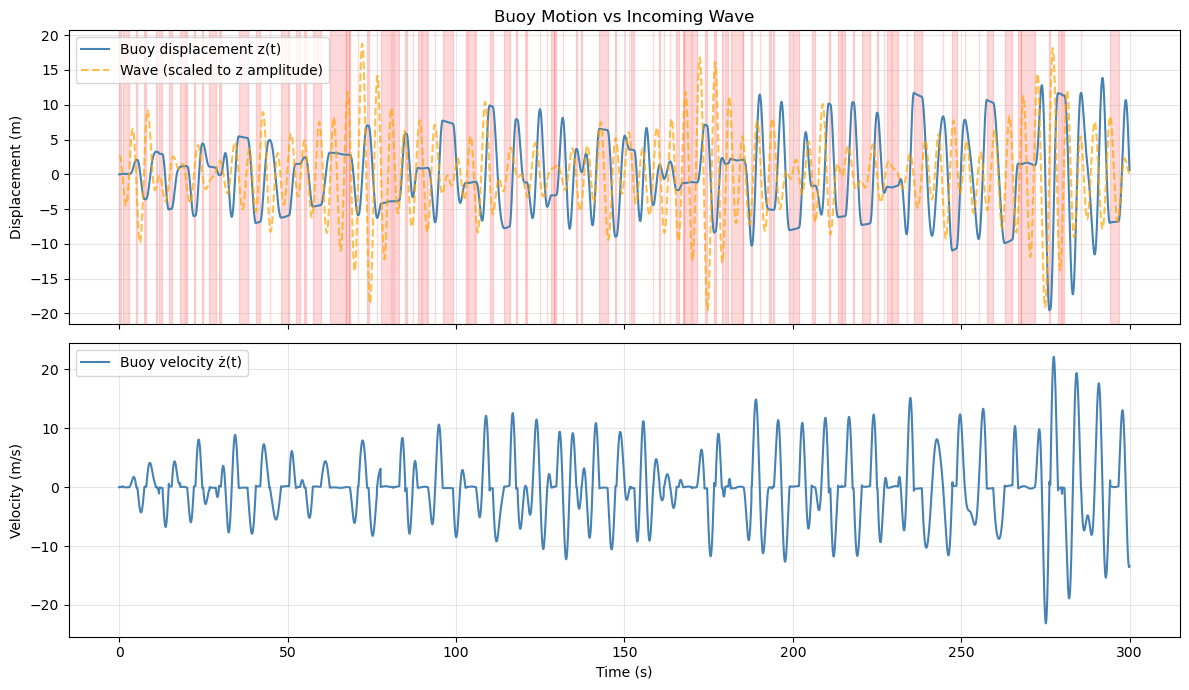

In [11]:
print("\nReady to call:")
latch_state, state_sol, adjoint_sol = pontryagin_sol(omega_range, B_rad, t_grid, params, f_ex, N = 11, max_iter = 100)
z_vals    = state_sol.sol(t_grid)[0]
zdot_vals = state_sol.sol(t_grid)[1]

print("latch_state is", latch_state)
indices = [i for i, value in enumerate(latch_state) if value == 1]

print("indices:", len(indices))

wave_norm = f_ex_vals / np.max(np.abs(f_ex_vals)) * np.max(np.abs(z_vals))
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top: displacement vs wave
axes[0].plot(t_grid, z_vals,    label='Buoy displacement z(t)', color='steelblue')
axes[0].plot(t_grid, wave_norm, label='Wave (scaled to z amplitude)', 
             color='orange', linestyle='--', alpha=0.7)

# Shade latched regions
in_latch = False
for i, t in enumerate(t_grid):
    if latch_state[i] == 1 and not in_latch:
        latch_start = t
        in_latch = True
    elif latch_state[i] == 0 and in_latch:
        axes[0].axvspan(latch_start, t, alpha=0.15, color='red', label='Latched' if latch_start == t_grid[0] else '')
        in_latch = False

axes[0].set(ylabel='Displacement (m)', title='Buoy Motion vs Incoming Wave')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: velocity
axes[1].plot(t_grid, zdot_vals, label='Buoy velocity ż(t)', color='steelblue')
axes[1].set(xlabel='Time (s)', ylabel='Velocity (m/s)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Now find the no latch motion of the bouy and resulting PTO.

[[ 3.57193516e+05 -2.53835595e-02  1.78596758e+05  6.32678943e-01]
 [ 1.78596758e+05 -4.06136951e-02  8.92983791e+04  1.26535789e+00]
 [ 1.19064505e+05 -5.58438308e-02  5.95322527e+04  1.89803683e+00]
 [ 8.92983791e+04 -7.10739665e-02  4.46491895e+04  2.53071577e+00]
 [ 7.14387033e+04 -8.63041021e-02  3.57193516e+04  3.16339471e+00]
 [ 5.95322527e+04 -1.01534238e-01  2.97661264e+04  3.79607366e+00]
 [ 5.10276452e+04 -1.16764373e-01  2.55138226e+04  4.42875260e+00]
 [ 4.46491895e+04 -1.31994509e-01  2.23245948e+04  5.06143154e+00]
 [ 3.96881685e+04 -1.47224645e-01  1.98440842e+04  5.69411048e+00]
 [ 3.57193516e+04 -1.62454781e-01  1.78596758e+04  6.32678943e+00]
 [ 3.24721378e+04 -1.77684916e-01  1.62360689e+04  6.95946837e+00]]
[[ 2.55349318e+05 -7.31274272e-01  1.36451009e+05  1.28513137e+00]
 [ 1.22508290e+05 -1.00000000e-03  4.73956455e+03  1.47617264e+00]
 [ 1.03056965e+05 -6.45460001e-01  2.34690851e+04  1.45838922e+00]
 [ 6.39362815e+04 -4.34620848e-01  1.19386142e+04  2.26218429

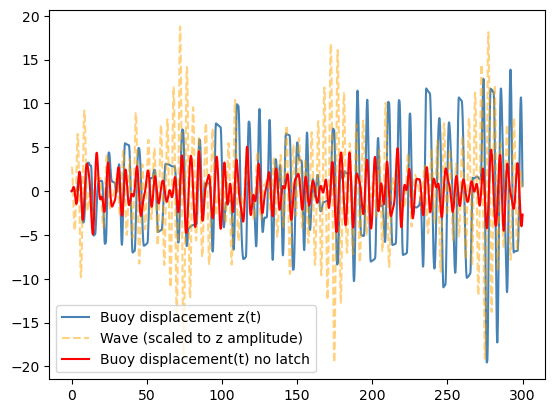

In [16]:
state_no_latch = no_latch_solution(omega_range, B_rad, t_grid, params, f_ex, N = 11)
zdot_vals_no_latch = state_no_latch.sol(t_grid)[1]
plt.plot(t_grid, z_vals,    label='Buoy displacement z(t)', color='steelblue')
plt.plot(t_grid, wave_norm, label='Wave (scaled to z amplitude)', color = "orange", linestyle='--', alpha=0.5)
plt.plot(t_grid, state_no_latch.sol(t_grid)[0], label='Buoy displacement(t) no latch', color='red')
plt.legend()
plt.show()

$$P = \frac{E}{T} = \frac{1}{T} \int_0^T B v^2 , dt$$

0.05


C:\Users\meerk\AppData\Local\Temp\ipykernel_22356\2266095427.py:12: RuntimeWarning: invalid value encountered in scalar divide
  power_t_no_latch.append(no_latch_E / t)
C:\Users\meerk\AppData\Local\Temp\ipykernel_22356\2266095427.py:15: RuntimeWarning: invalid value encountered in scalar divide
  power_so_far = total_energy_so_far / t


(<matplotlib.legend.Legend at 0x167a17dd820>,
 <matplotlib.legend.Legend at 0x167aaa62180>)

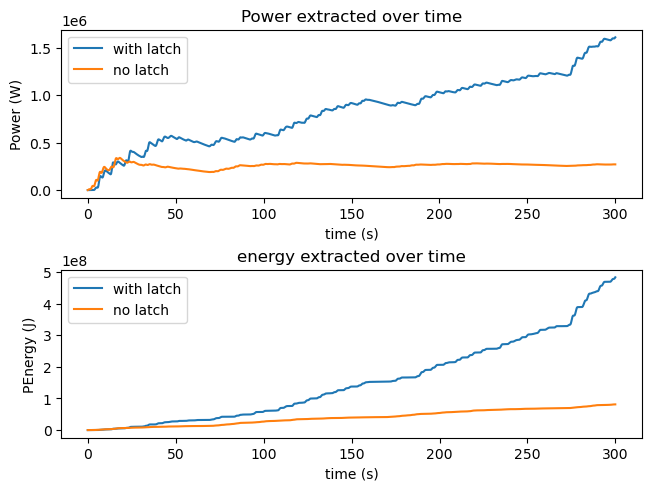

In [17]:
dt = t_grid[1] - t_grid[0]
print(dt)
total_energy = np.sum(d * zdot_vals**2 * dt)
power_extracted = total_energy / t_grid[-1]
power_t_no_latch = []
energy_t_no_latch = []
power_t = []
energy_t = []
for i, t in enumerate(t_grid):
    no_latch_E = np.sum(d * zdot_vals_no_latch[:i]**2 * dt)
    energy_t_no_latch.append(no_latch_E)
    power_t_no_latch.append(no_latch_E / t)

    total_energy_so_far = np.sum(d * zdot_vals[:i]**2 * dt)
    power_so_far = total_energy_so_far / t
    power_t.append(power_so_far)
    energy_t.append(total_energy_so_far)

fig, axs = plt.subplots(2, layout= "constrained")
axs[0].plot(t_grid,power_t, label = "with latch")
axs[0].plot(t_grid, power_t_no_latch, label='no latch')
axs[0].set_title('Power extracted over time')
axs[0].set_xlabel('time (s)'), axs[0].set_ylabel('Power (W)')
axs[1].plot(t_grid, energy_t, label = "with latch")
axs[1].plot(t_grid, energy_t_no_latch, label='no latch')
axs[1].set_title('energy extracted over time')
axs[1].set_xlabel('time (s)'), axs[1].set_ylabel('PEnergy (J)')
axs[1].legend(), axs[0].legend()